# Lab 3: Exploring 1D Data Visualizations

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/AirIndia.csv')


In [13]:
# Clean column names
df.columns = [col.strip().replace('\n','') for col in df.columns]

In [14]:
# Convert relevant columns to numeric (some have "(TH)" in name)
num_cols = ['DEPARTURES', 'HOURS', 'KILOMETER(TH)', 'PASSENGERS CARRIED', 
            'PASSENGER KMS. PERFORMED(TH)', 'AVAILABLE SEAT KILOMETRE(TH)', 'PAX. LOAD FACTOR#(IN %)']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

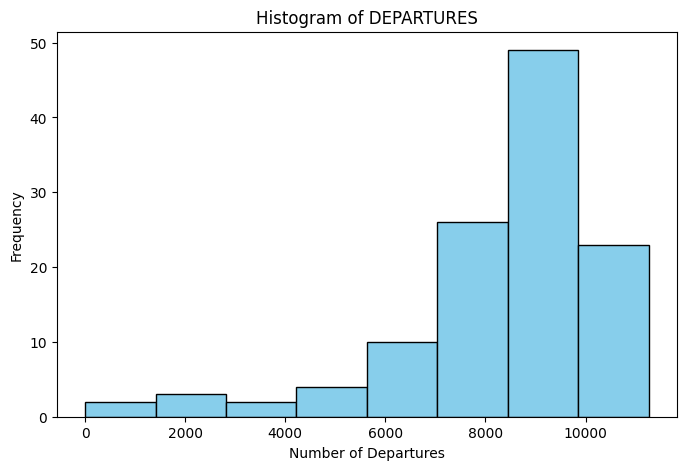

Dataset Source: AirIndia.csv contains monthly airline operation stats.
Feature: DEPARTURES - Number of flights departed each month.



In [15]:
# ========== 1. HISTOGRAMS (Numerical Data) ==========

# Standard Histogram - DEPARTURES
plt.figure(figsize=(8,5))
plt.hist(df['DEPARTURES'].dropna(), bins=8, color='skyblue', edgecolor='black')
plt.title('Histogram of DEPARTURES')
plt.xlabel('Number of Departures')
plt.ylabel('Frequency')
plt.show()

print("Dataset Source: AirIndia.csv contains monthly airline operation stats.")
print("Feature: DEPARTURES - Number of flights departed each month.\n")

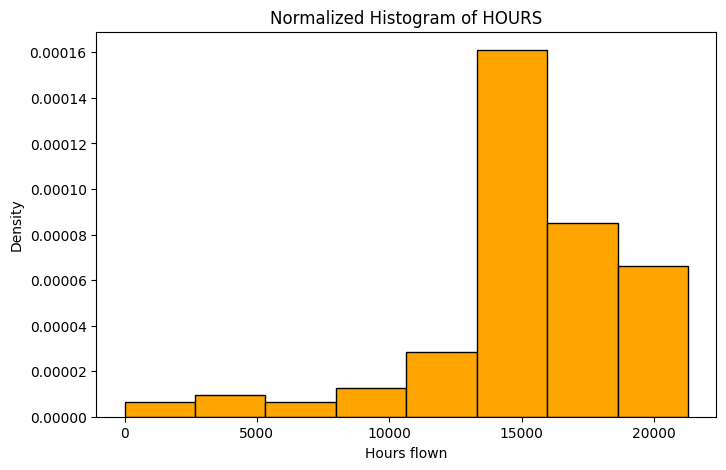

Feature: HOURS - Total flying hours per month, shown as density.



In [16]:
# Normalized Histogram - HOURS
plt.figure(figsize=(8,5))
plt.hist(df['HOURS'].dropna(), bins=8, color='orange', edgecolor='black', density=True)
plt.title('Normalized Histogram of HOURS')
plt.xlabel('Hours flown')
plt.ylabel('Density')
plt.show()

print("Feature: HOURS - Total flying hours per month, shown as density.\n")

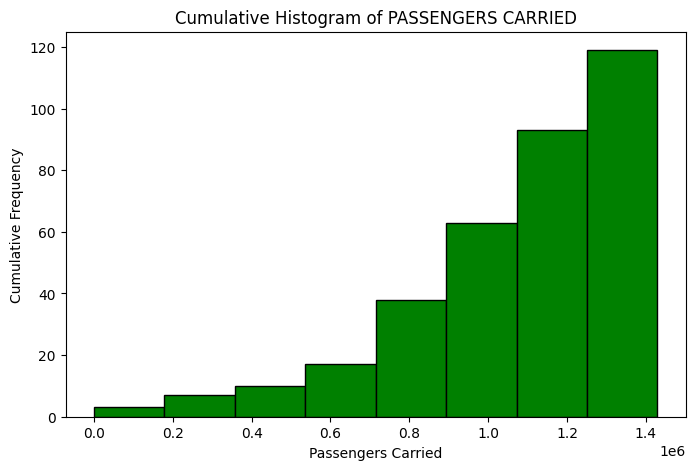

Feature: PASSENGERS CARRIED - Cumulative count of passengers per month.



In [17]:
# Cumulative Histogram - PASSENGERS CARRIED
plt.figure(figsize=(8,5))
plt.hist(df['PASSENGERS CARRIED'].dropna(), bins=8, cumulative=True, color='green', edgecolor='black')
plt.title('Cumulative Histogram of PASSENGERS CARRIED')
plt.xlabel('Passengers Carried')
plt.ylabel('Cumulative Frequency')
plt.show()

print("Feature: PASSENGERS CARRIED - Cumulative count of passengers per month.\n")

C:\Users\Himal\AppData\Local\Temp\ipykernel_11688\1455106728.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['KILOMETER(TH)'].dropna(), shade=True, color='purple')


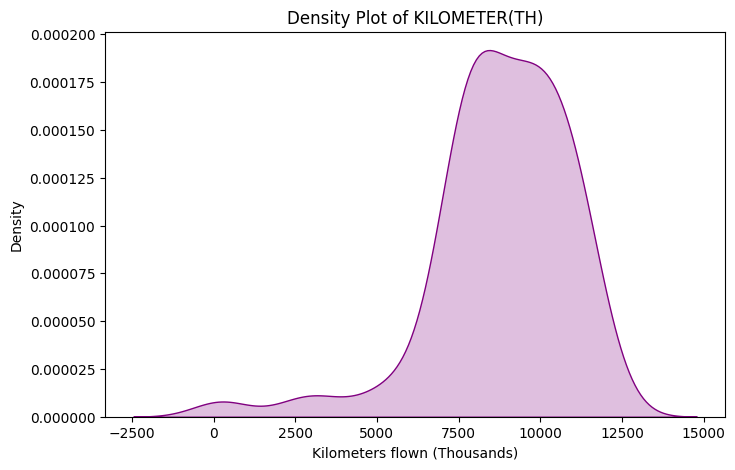

Feature: KILOMETER(TH) - Distribution of distance flown in thousands of km.



In [18]:
# KDE / Density Plot - KILOMETER(TH)
plt.figure(figsize=(8,5))
sns.kdeplot(df['KILOMETER(TH)'].dropna(), shade=True, color='purple')
plt.title('Density Plot of KILOMETER(TH)')
plt.xlabel('Kilometers flown (Thousands)')
plt.ylabel('Density')
plt.show()

print("Feature: KILOMETER(TH) - Distribution of distance flown in thousands of km.\n")

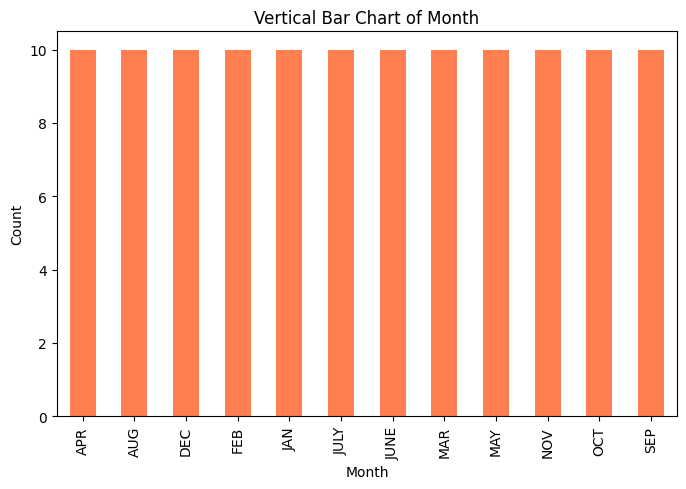

Feature: Month - Count of records per month (categorical).



In [19]:
# ========== 2. BAR PLOTS (Categorical Data) ==========

# Vertical Bar Chart - Month count (should be uniform)
plt.figure(figsize=(8,5))
df['Month'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Vertical Bar Chart of Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

print("Feature: Month - Count of records per month (categorical).\n")

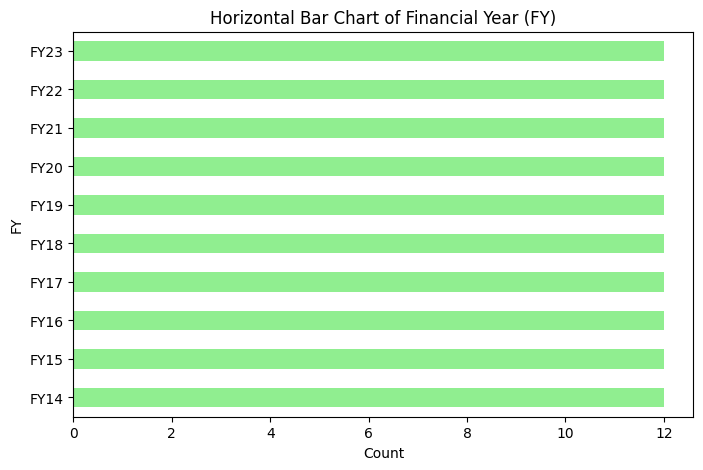

Feature: FY - Distribution of data by financial year.



In [20]:
# Horizontal Bar Chart - FY counts
plt.figure(figsize=(8,5))
df['FY'].value_counts().plot(kind='barh', color='lightgreen')
plt.title('Horizontal Bar Chart of Financial Year (FY)')
plt.xlabel('Count')
plt.ylabel('FY')
plt.show()

print("Feature: FY - Distribution of data by financial year.\n")

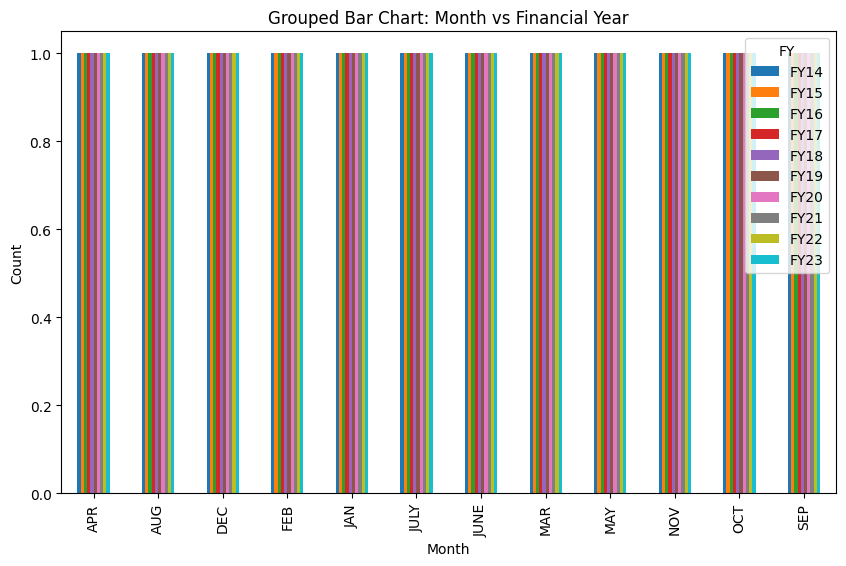

Grouped counts of months split by financial year.



In [21]:
# Grouped Bar Chart - Month vs FY counts
cross_tab = pd.crosstab(df['Month'], df['FY'])
cross_tab.plot(kind='bar', figsize=(10,6))
plt.title('Grouped Bar Chart: Month vs Financial Year')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

print("Grouped counts of months split by financial year.\n")

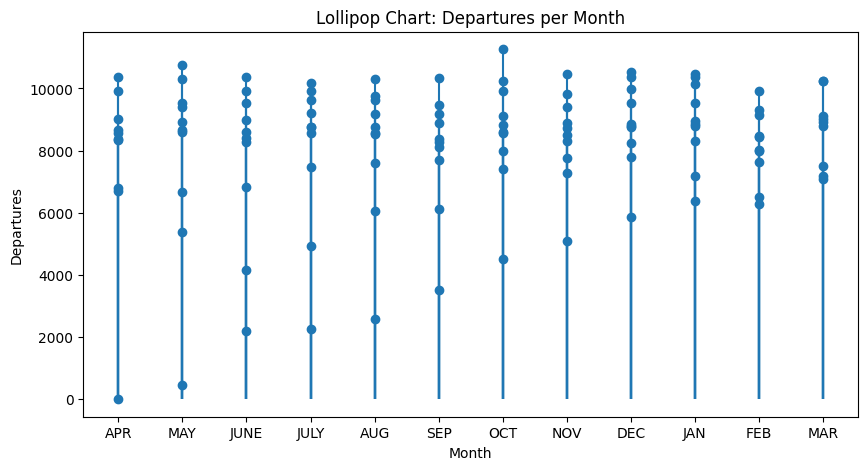

Departures lollipop chart showing number of departures each month.



In [22]:
plt.figure(figsize=(10,5))
plt.stem(df['Month'], df['DEPARTURES'], basefmt=" ")
plt.title('Lollipop Chart: Departures per Month')
plt.xlabel('Month')
plt.ylabel('Departures')
plt.show()

print("Departures lollipop chart showing number of departures each month.\n")


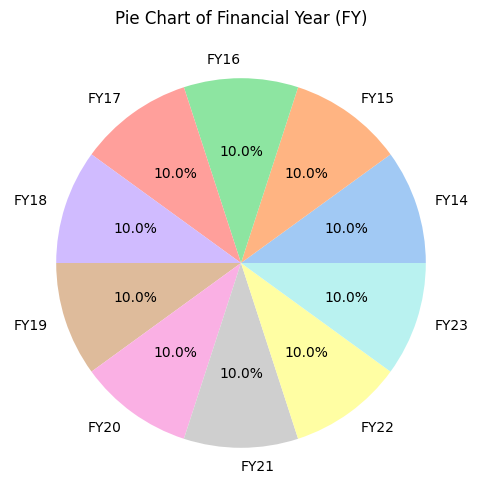

Proportion of records in each financial year (FY).



In [23]:
# ========== 3. PIE CHARTS (Category Proportion) ==========

# Standard Pie Chart - FY proportion
plt.figure(figsize=(6,6))
df['FY'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Pie Chart of Financial Year (FY)')
plt.ylabel('')
plt.show()

print("Proportion of records in each financial year (FY).\n")

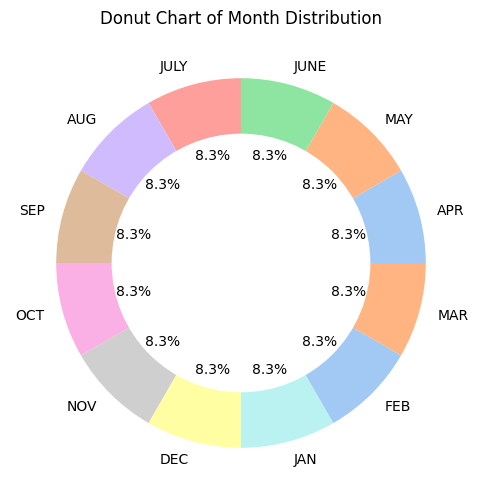

Donut chart showing proportion of data per month.



In [24]:
# Donut Chart - Month proportion
plt.figure(figsize=(6,6))
sizes = df['Month'].value_counts()
colors = sns.color_palette('pastel')
plt.pie(sizes, labels=sizes.index, autopct='%1.1f%%', colors=colors)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Donut Chart of Month Distribution')
plt.show()

print("Donut chart showing proportion of data per month.\n")

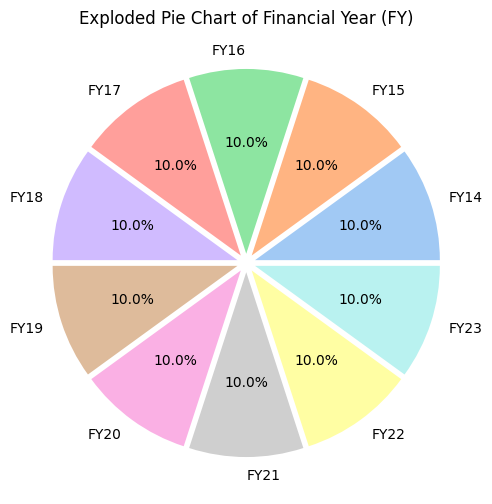

Exploded pie chart to emphasize FY distribution.



In [25]:
# Exploded Pie Chart - FY
plt.figure(figsize=(6,6))
explode = [0.05]*len(df['FY'].unique())
df['FY'].value_counts().plot.pie(autopct='%1.1f%%', explode=explode, colors=colors)
plt.title('Exploded Pie Chart of Financial Year (FY)')
plt.ylabel('')
plt.show()

print("Exploded pie chart to emphasize FY distribution.\n")


In [26]:
# ========== 4. BOX PLOTS (Statistical Summary) ==========

# Calculate summary statistics for DEPARTURES
desc = df['DEPARTURES'].describe()
print(f"Statistical Summary for DEPARTURES:\n{desc}\n")


Statistical Summary for DEPARTURES:
count      119.000000
mean      8247.680672
std       2036.087774
min          0.000000
25%       7656.500000
50%       8732.000000
75%       9520.500000
max      11262.000000
Name: DEPARTURES, dtype: float64



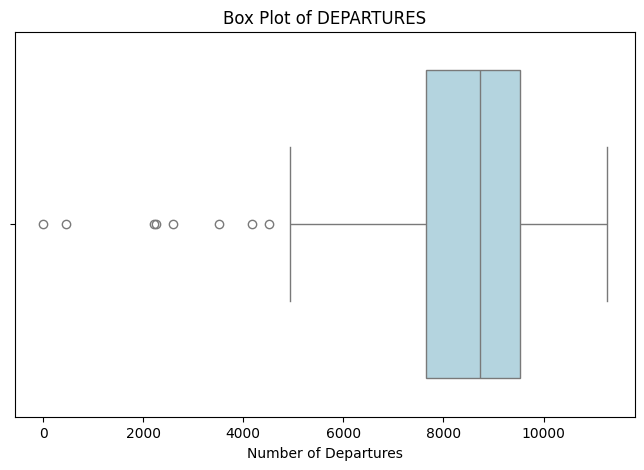

In [27]:
# Standard Box Plot - DEPARTURES
plt.figure(figsize=(8,5))
sns.boxplot(x=df['DEPARTURES'], color='lightblue')
plt.title('Box Plot of DEPARTURES')
plt.xlabel('Number of Departures')
plt.show()

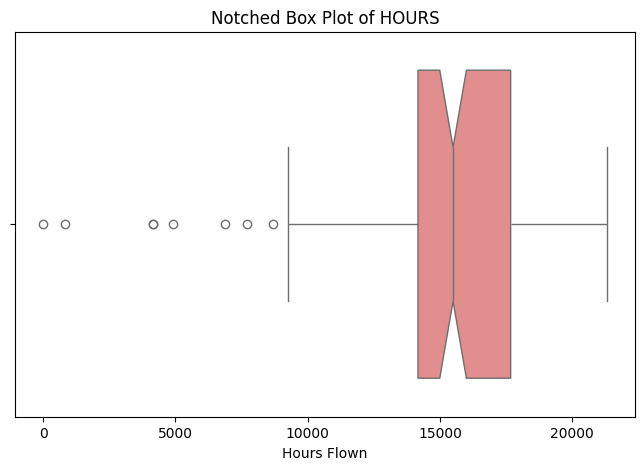

In [28]:
# Notched Box Plot - HOURS
plt.figure(figsize=(8,5))
sns.boxplot(x=df['HOURS'], notch=True, color='lightcoral')
plt.title('Notched Box Plot of HOURS')
plt.xlabel('Hours Flown')
plt.show()


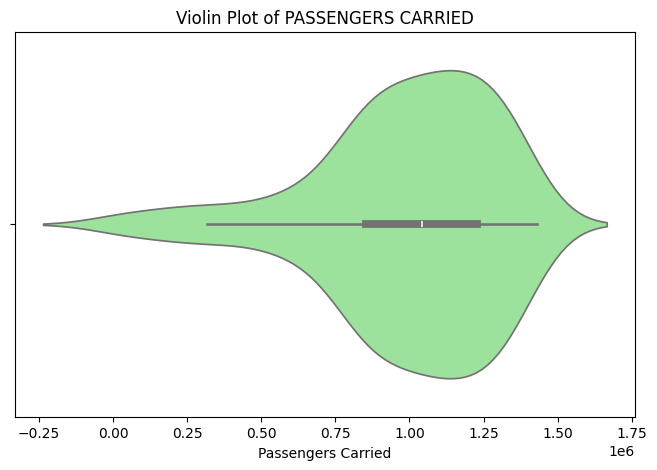

In [29]:
# Violin Plot - PASSENGERS CARRIED
plt.figure(figsize=(8,5))
sns.violinplot(x=df['PASSENGERS CARRIED'], color='lightgreen')
plt.title('Violin Plot of PASSENGERS CARRIED')
plt.xlabel('Passengers Carried')
plt.show()

C:\Users\Himal\AppData\Local\Temp\ipykernel_11688\467685900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FY', y='PASSENGERS CARRIED', data=df, palette='pastel')


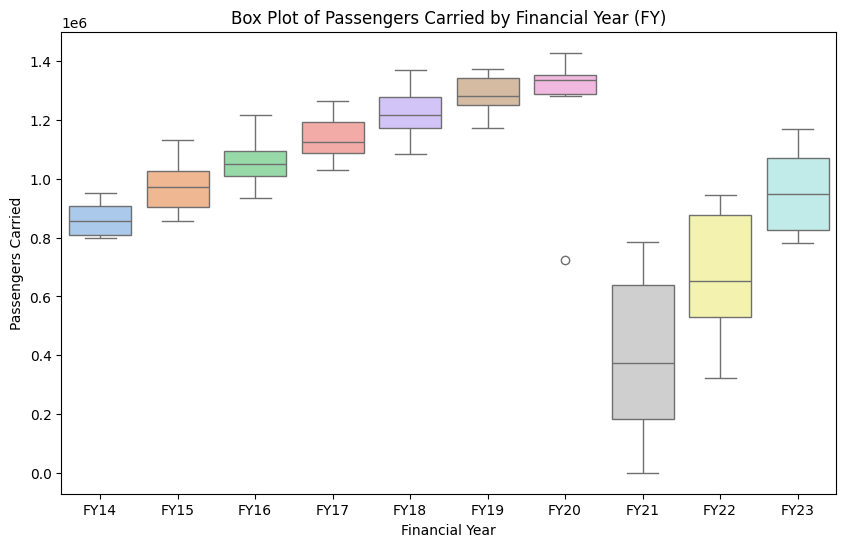

In [30]:
# Side-by-side Box Plot - PASSENGERS CARRIED by FY
plt.figure(figsize=(10,6))
sns.boxplot(x='FY', y='PASSENGERS CARRIED', data=df, palette='pastel')
plt.title('Box Plot of Passengers Carried by Financial Year (FY)')
plt.xlabel('Financial Year')
plt.ylabel('Passengers Carried')
plt.show()